# Work on point source response

In [1]:
%run pylib/tools dark
from utilities.ipynb_docgen import show
from importlib import reload
from like3 import demo_model as dm; reload(dm)
from like3 import likelihood as lk; reload(lk)

from pylib.kerr_funcs import *
self = KerrModel()

Loaded Kerr model from "files/from-kerr/toby_v1.npz":
            43 bands Band(0, 4): psf0@1.33 GeV nside 64 occ 1.000 ... Band(3, 11): psf3@74.99 GeV nside 2048 occ 0.000
            206,555,017 photons


PSF3 nsides: [  16   32   64  128  256  512  512  512 1024 2048 2048 2048]


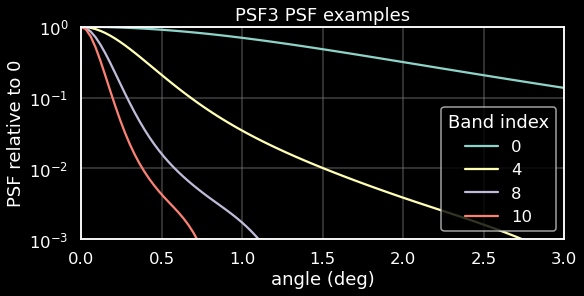

In [2]:
nside_list = self.meta_df.query('event_type=="psf3" & emin>=100').nside.values
print('PSF3 nsides:', nside_list)
%run pylib/psf_func
PSFlist.example_plot(title='PSF3 PSF examples')

In [3]:
plist = PSFlist(event_type=0)[:12]; plist[:12]
df = pd.DataFrame(plist)
df['nside'] = nside_list
df.drop('event_type', axis=1, inplace=True)
df['psf'] = plist
df


,r68,energy,nside,psf
0,3.230,133.0,16,"{'r68': 3.23, 'energy': 133.0, 'event_type': 0}"
1,2.044,237.0,32,"{'r68': 2.044, 'energy': 237.0, 'event_type': 0}"
2,1.239,422.0,64,"{'r68': 1.239, 'energy': 422.0, 'event_type': 0}"
3,0.739,750.0,128,"{'r68': 0.739, 'energy': 750.0, 'event_type': 0}"
4,0.444,1334.0,256,"{'r68': 0.444, 'energy': 1334.0, 'event_type': 0}"
5,0.281,2371.0,512,"{'r68': 0.281, 'energy': 2371.0, 'event_type': 0}"
6,0.185,4217.0,512,"{'r68': 0.185, 'energy': 4217.0, 'event_type': 0}"
7,0.127,7499.0,512,"{'r68': 0.127, 'energy': 7499.0, 'event_type': 0}"
8,0.092,13335.0,1024,"{'r68': 0.092, 'energy': 13335.0, 'event_type'..."
9,0.074,23714.0,2048,"{'r68': 0.074, 'energy': 23714.0, 'event_type'..."


	name  : Test
	ICRS  : (000.000, +20.000)
	model : LogParabola
		Norm      : 1e-14 
		Index     : 2.2 
		beta      : 0 (FROZEN)
		E_break   : 1e+03 (FROZEN)


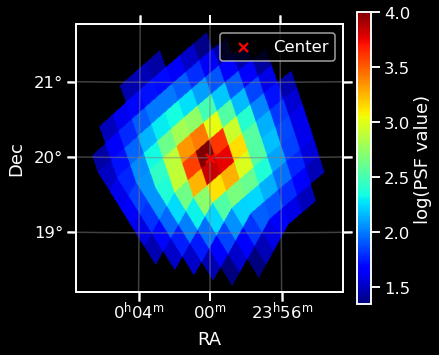

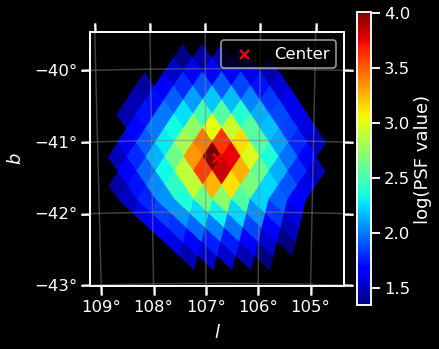

In [ ]:
from like3 import sources; reload(sources)
from like3 import response; reload(response)
from like3.response import PointResponse
from like3.sources import PointSource


src = PointSource(name='Test', skydir=(0,20), ); print(src)
rsp = src.response( df.iloc[4])
rsp.plot_psf_map(frame='icrs')
rsp.plot_psf_map(frame='galactic')


---

In [9]:
show(f""" MRK 501 counts spectrum, spectral pars""")
c=np.array([  7.60060000e+03,   6.69100000e+03,   4.52130000e+03,
         2.51500000e+03,   1.18760000e+03,   4.83900000e+02,
         1.71700000e+02,   5.57000000e+01,   1.69000000e+01,
         4.80000000e+00,   1.30000000e+00,   3.00000000e-01]).astype(int)
model_pars = np.array([  5.77195540e-11,   2.35199847e+00,   1.25274314e-01,
         5.69634604e+02])
c, model_pars

MRK 501 counts spectrum, spectral pars

(array([7600, 6691, 4521, 2515, 1187,  483,  171,   55,   16,    4,    1,    0]),
 array([5.77195540e-11, 2.35199847e+00, 1.25274314e-01, 5.69634604e+02]))

In [10]:
self.summary()

AttributeError: 'KerrModel' object has no attribute 'summary'

In [ ]:
f = model.sources[0].model
f.gradient(model.energies)

array([[ 3.22824859e-11,  5.54552312e-11,  9.27309799e-11,  1.47813250e-10,  2.16383764e-10,  2.72257696e-10,
         2.61699839e-10,  1.55843471e-10,  3.96097109e-11,  2.21491274e-12,  8.38666936e-15,  2.64509394e-19],
       [ 3.39318388e-11,  4.44247010e-11,  5.11032325e-11,  4.45052774e-11,  1.10553189e-11, -5.41544356e-11,
        -1.17479345e-10, -1.08920364e-10, -3.75860009e-11, -2.65547824e-12, -1.21515185e-14, -4.49377321e-19],
       [-2.43592097e-11, -2.78017141e-11, -2.55040574e-11, -1.42800694e-11, -7.20153252e-13, -1.67318012e-11,
        -1.01756676e-10, -1.86232783e-10, -1.12990656e-10, -1.33432641e-11, -9.97043507e-14, -5.96218263e-18],
       [ 5.70051578e-12,  5.44749714e-12,  3.78427800e-12,  1.27562188e-12,  1.20259458e-14, -1.19652588e-12,
        -1.80110319e-11, -5.60425794e-11, -5.01370214e-11, -8.07288656e-12, -7.81305714e-14, -5.82947366e-18]])

In [ ]:
self.fit()
f.pivot_energy()

17 calls, log like improvement, quality:  -28.62, 16.29
Name                  index     value  error(%)  gradient
PSR_Norm                  0  1.12e-10       5.4       0.5
   _Index                 1         0764451333449013395456.0     102.4
   _Curvature             2    0.7894       7.3      -1.8
   _b                     3  -0.02907     523.6      -2.0


/mnt/c/users/thbur/onedrive/work/kerr-diffuse/like3/spectral_models.py:2028: RuntimeWarning: overflow encountered in power
  return n0*x**(-gamma+d/b)*np.exp((d/b**2)*(1-x**b))
/mnt/c/users/thbur/onedrive/work/kerr-diffuse/like3/spectral_models.py:2028: RuntimeWarning: overflow encountered in exp
  return n0*x**(-gamma+d/b)*np.exp((d/b**2)*(1-x**b))
/mnt/c/users/thbur/onedrive/work/kerr-diffuse/like3/spectral_models.py:2028: RuntimeWarning: overflow encountered in power
  return n0*x**(-gamma+d/b)*np.exp((d/b**2)*(1-x**b))
/mnt/c/users/thbur/onedrive/work/kerr-diffuse/like3/spectral_models.py:2028: RuntimeWarning: overflow encountered in exp
  return n0*x**(-gamma+d/b)*np.exp((d/b**2)*(1-x**b))
/mnt/c/users/thbur/onedrive/work/kerr-diffuse/like3/spectral_models.py:2028: RuntimeWarning: overflow encountered in power
  return n0*x**(-gamma+d/b)*np.exp((d/b**2)*(1-x**b))
/mnt/c/users/thbur/onedrive/work/kerr-diffuse/like3/spectral_models.py:2028: RuntimeWarning: overflow encountered in ex

1656.77490234375

In [ ]:
gv = self.gradient();
H = np.array(self.hessian()); 
np.linalg.inv(H)
# np.dot(np.dot(gv, np.linalg.inv(H)), gv)/4

array([[ 0.00051508, -0.00018087,  0.00027421],
       [-0.00018087,  0.00095551, -0.00013402],
       [ 0.00027421, -0.00013402,  0.00034646]])

In [ ]:
from like3 import sourcelist as sl; reload(sl)
from like3 import sources as src; reload(src)
from like3.spectral_models import LogParabola
lp = LogParabola((1e-10, 0.25, 0.2, 1000 ))
s = src.PointSource(name='test1', skydir=(0,0),  model=lp )  
srclist = sl.SourceList([s])
srclist.parameters.values

1 total sources: 3 free parameters


array([-10.  ,   0.25,   0.2 ])

In [ ]:
show(f""" ## SimpleModel has to evaluate response from a SourceList """)
self = sm.SimpleModel(srclist)
self()

## SimpleModel has to evaluate response from a SourceList 

array([ 73.47957871,  94.70230282, 106.90297572, 105.69499477,  91.52809463,  69.42082879,  46.11694603,  26.83284103,
        13.67439587,   6.10358521,   2.38614729,   0.81704289])

In [ ]:
from like3 import likelihood as lk; reload(lk);
model = sm.SimpleModel(srclist)
self = lk.Likelihood(model, parameters=srclist.parameters, data=model.simulate())
self.fit()

7 calls, function value, improvement, quality: 2108.6, -0.01, 0.04
Name                  index     value  error(%)  gradient
test1_Norm                0 9.575e-11       5.3      29.3
     _Index               1    0.2511      12.4      -2.9
     _beta                2    0.1632      11.4     -58.1


In [ ]:
self.fit([0])

7 calls, function value, improvement, quality: 2108.6, 0.24, 0.04
Name                  index     value  error(%)  gradient
test1_Norm                0 9.576e-11       5.3      29.5
     _Index               1    0.2516      12.3      -2.3
     _beta                2    0.1632      11.4     -57.9


In [ ]:
self.parameterset.ms

[(like3.sources.PointSource: 
  	name  : test1
  	skydir: SkyDir(0.000, 0.000)
  	model : LogParabola
  				Norm      : (1 + 0.054 - 0.051) (avg = 0.053) 9.58e-11   
  		Index     : (1 + 0.123 - 0.123) (avg = 0.123) 0.252      
  		beta      : (1 + 0.114 - 0.114) (avg = 0.114) 0.163      
  		E_break   : (1 + 0.000 - 0.000) (avg = 0.000) 1e+03      (FROZEN)
  		Ph. Flux  : (1 + 0.129 - 0.115) (avg = 0.122) 9.61e-07   (DERIVED)
  		En. Flux  : (1 + 0.372 - 0.271) (avg = 0.318) 4.21e-08   (DERIVED),
  3)]

# Combine bands above,say, 100 MeV for plots

In [ ]:
%run pylib/tools dark
from utilities.ipynb_docgen import show
from importlib import reload
from pylib import kerr_funcs; reload(kerr_funcs)
from pylib.kerr_funcs import *
self = KerrModel('../pointlike/from-kerr/toby_v2')

Loaded Kerr model from "../pointlike/from-kerr/toby_v2.npz":
            43 bands Band(0, 4): psf0@1.33 GeV nside 64 occ 1.000 ... Band(3, 11): psf3@74.99 GeV nside 2048 occ 0.000
            206,555,017 photons


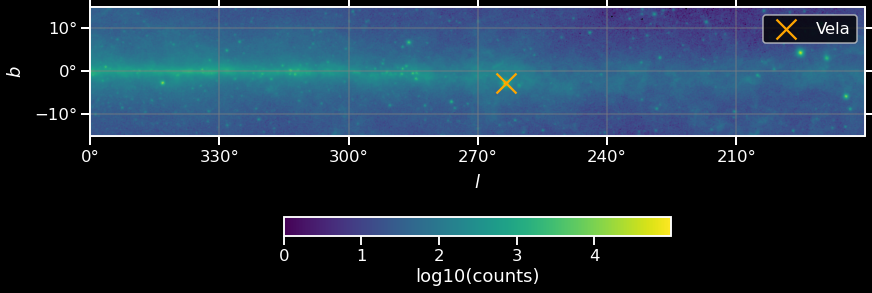

In [ ]:
z = self.zea_plot( (-90,0), component='data', nside=256,figsize=(12,8), size=(180,30), proj='CAR',frame='galactic', colorbar=False)\
    .colorbar(shrink=0.5, orientation='horizontal', label='log10(counts)')\
    .scatter('Vela pulsar', color='orange', s=400, marker='x', label='Vela')\
    .legend()\
    .show()

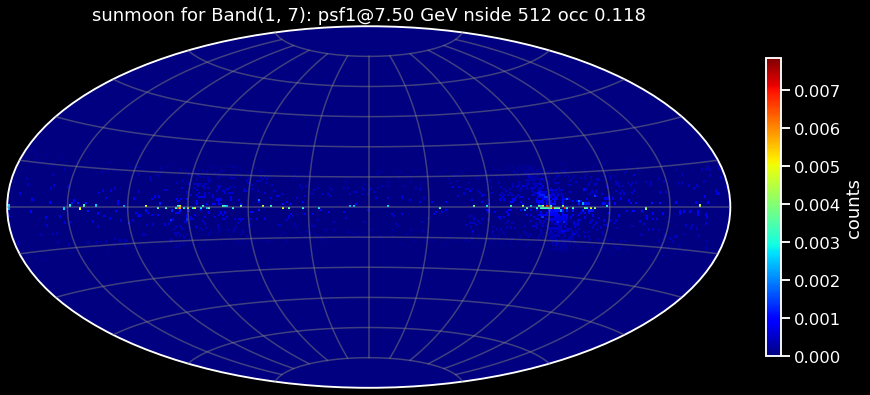

In [ ]:
self(1,7).ait_plot('sunmoon', nside=512, cmap='jet',frame='barycentricmeanecliptic', log=False, ).show()

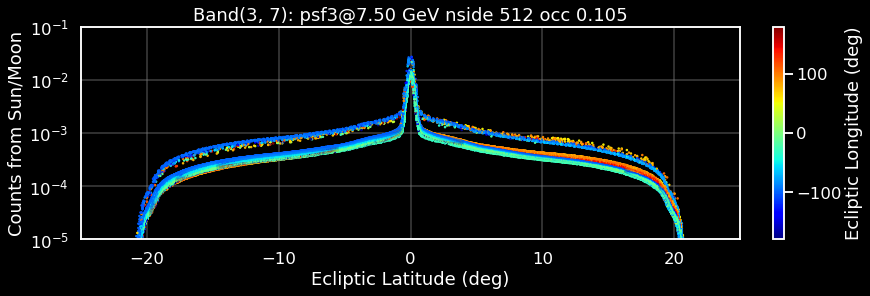

In [ ]:
b = self(3,7)
v =b.ring_map(component='sunmoon', frame='barycentricmeanecliptic')
lon,lat = HEALPix(nside=512).healpix_to_lonlat(np.arange(12*512*512)) 
lon = lon.deg; lon[lon>180]-=360
plt.figure(figsize=(12,4))
plt.scatter(x=lat.deg, y=v, c=lon, s=1, cmap='jet');
plt.colorbar(label='Ecliptic Longitude (deg)')
plt.gca().set(yscale='log', xlim=(-25,25), title=str(b),
ylim=(1e-5,1e-1),xlabel='Ecliptic Latitude (deg)', ylabel='Counts from Sun/Moon');

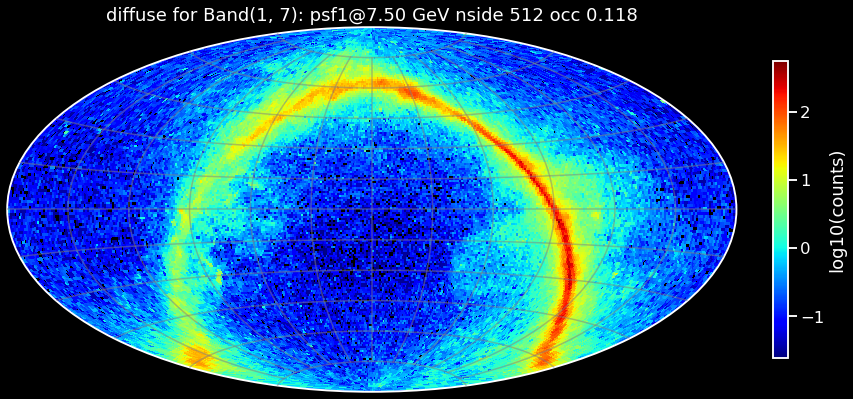

In [ ]:
self(1,7).ait_plot('diffuse', nside=64, cmap='jet',frame='barycentricmeanecliptic');

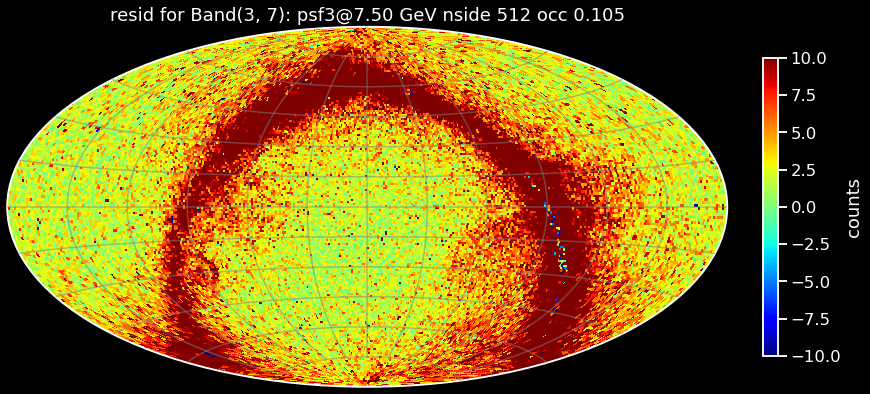

In [ ]:
self(3,7).ait_plot('resid', nside=64, cmap='jet',frame='barycentricmeanecliptic', log=False, vmin=-10, vmax=10);

In [ ]:
import pickle
def read_loc( et='psf'):
    order = 'PSF0 PSF1 PSF2 PSF3 all'.split() if et=='psf' else 'front back all'.split()
    with open(f'files/geminga_loc_{et}.pkl', 'rb') as f:
        fb = pickle.load(f , encoding='latin1')  
        df = pd.DataFrame.from_dict(fb, orient='index', columns='ra dec a b ang qual unk'.split())
        df['r95'] = 2.45 * np.sqrt(df.a*df.b)
        df['iv'] = round(1/df.a/df.b)
    return df.loc[order,:]

psf = read_loc()
fb = read_loc('fb')

FileNotFoundError: [Errno 2] No such file or directory: 'files/geminga_loc_psf.pkl'

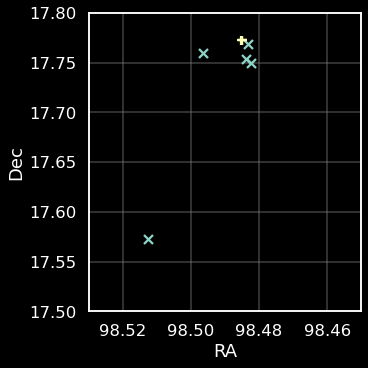

In [ ]:
fig,ax =plt.subplots(figsize=(5,5))
ax.scatter(psf.ra, psf.dec, marker='x');
ax.scatter(fb.ra, fb.dec, marker='+');
ax.set(xlim=(98.53, 98.45), ylim=(17.5, 17.8), xlabel='RA', ylabel='Dec');

In [ ]:
from importlib import reload
from pylib import kerr_funcs; reload(kerr_funcs)
from pylib.kerr_funcs import *
self = KerrModel('../pointlike/from-kerr/toby_v1')

In [ ]:
show(f'## Compare total model flux for each band to data')
d={}
for k,v in self.items():
    model_sum = np.sum(v.diffuse) + np.sum(v.ptsrc) 
    model_total = v.totals['diffuse'] + v.totals['ptsrc']
    d[k] = dict(psfn=k[0],energy_bin=k[1], nside=v.nside, model_total=model_total.round(1), 
                model_sum=model_sum.round(1), photons=  np.sum(v.photons), npix=len(v.pix))

df = pd.DataFrame.from_dict(d, orient='index')
mt = df.model_total.values.astype(float)
df['residual'] = ((df.photons/mt-1)/np.sqrt(mt)).round(4)

df.index.name = 'band'
df

## Compare total model flux for each band to data

psfn  energy_bin  nside  model_total   model_sum   photons     npix  \
0  4      0           4     64    5877063.6   5877510.7   5885074    49152   
   5      0           5     64    2951105.3   2949507.0   2936033    49152   
   6      0           6    128    1264668.8   1233820.6   1263401   180405   
   7      0           7    128     520898.7    465458.8    521628   144473   
   8      0           8    128     220549.4    164143.9    219736    97993   
   9      0           9    256      90771.5     27814.1     89374    72060   
   10     0          10    256      39809.6      7816.7     39805    34948   
   11     0          11    256      16694.8      2097.8     16992    15665   
1  2      1           2     32   15066619.8  15064791.5  14903613    12288   
   3      1           3     64    9900517.9   9901295.4   9882162    49152   
   4      1           4    128    5890372.1   5889935.7   5888985   196464   
   5      1           5    256    2860647.3   2661179.4   2866732   597768   
   6      1           6    256    1252355.1   1037250.0   1268818   425755   
   7      1           7    512     518241.4    213935.6    521152   370760   
   8      1           8    512     212697.0     55140.7    210773   174106   
   9      1           9    512      87672.9     13096.5     85922    76836   
   10     1          10    512      36696.6      3166.7     36027    33630   
   11     1          11    512      15308.2       815.5     15122    14420   
2  0      2           0     16   17843385.3  17835516.9  17835246     3072   
   1      2           1     32   18353543.0  18351665.6  18303506    12288   
   2      2           2     64   15781446.9  15781958.0  15803813    49152   
   3      2           3     64   10344391.3  10344421.5  10388617    49152   
   4      2           4    128    5940865.8   5940017.1   5960801   196428   
   5      2           5    256    2773733.9   2571452.4   2779917   583205   
   6      2           6    512    1153303.4    665635.6   1170999   676076   
   7      2           7    512     473055.3    190235.3    478553   341873   
   8      2           8   1024     193860.1     20895.5    191640   175312   
   9      2           9   1024      82371.8      4589.6     81150    76766   
   10     2          10   1024      38043.0      1286.8     37623    36148   
   11     2          11   1024      16720.1       376.9     15858    15419   
3 -1      3          -1      8   13312208.0  13297768.8  13237521      768   
   0      3           0     16   18156177.3  18153466.2  18345342     3072   
   1      3           1     32   18396774.3  18397915.1  18317659    12288   
   2      3           2     64   15773069.6  15775383.6  15813747    49152   
   3      3           3    128   10504419.0  10506451.6  10584802   196608   
   4      3           4    256    5890983.0   5758968.5   5867644   708284   
   5      3           5    512    2770813.9   2051305.1   2725670  1166781   
   6      3           6    512    1159375.7    674789.4   1177921   667396   
   7      3           7    512     463943.6    186033.9    467200   330712   
   8      3           8   1024     188541.1     19989.2    188379   170525   
   9      3           9   2048      80006.1      1561.0     78613    75967   
   10     3          10   2048      35794.8       438.4     36116    35163   
   11     3          11   2048      15569.7       139.5     15331    15009   

       residual  
0  4     0.0000  
   5    -0.0000  
   6    -0.0000  
   7     0.0000  
   8    -0.0000  
   9    -0.0001  
   10   -0.0000  
   11    0.0001  
1  2    -0.0000  
   3    -0.0000  
   4    -0.0000  
   5     0.0000  
   6     0.0000  
   7     0.0000  
   8    -0.0000  
   9    -0.0001  
   10   -0.0001  
   11   -0.0001  
2  0    -0.0000  
   1    -0.0000  
   2     0.0000  
   3     0.0000  
   4     0.0000  
   5     0.0000  
   6     0.0000  
   7     0.0000  
   8    -0.0000  
   9    -0.0001  
   10   -0.0001  
   11   -0.0004  
3 -1    -0.0000 